Desc: To predict the cliff distance (hdist where rel drops) for a given height, MCS, USI.

## Common imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

def find_cliff_hdist(df, threshold):
    """
    Identify the 'cliff' point in the data where the value drops significantly.
    The cliff is defined as the horizontal distance where the reliability first drops below the threshold.

    Parameters:
    df (pd.DataFrame): DataFrame for a combination of height, USI, and Bitrate. The columns are 'Horizontal_Distance' and 'Reliability'.
    threshold (float): The reliability threshold (e.g., 0.99).

    Returns:
    hdist: The horizontal distance of the cliff point (where reliability first drops below threshold).
           Returns 0 if no cliff is found or all values are below threshold.
    """
    # Sort by horizontal distance to find the first point where reliability drops below threshold
    df_sorted = df.sort_values('Horizontal_Distance').reset_index(drop=True)
    
    if df_sorted.empty:
        return 0
    
    # Find the first index where reliability drops below threshold
    below_threshold = df_sorted[df_sorted['Reliability'] < threshold]
    
    if below_threshold.empty:
        # No point drops below threshold, return the max horizontal distance
        return df_sorted['Horizontal_Distance'].max()
    
    # Return the horizontal distance of the first point below threshold
    return below_threshold['Horizontal_Distance'].iloc[0]

## Quadratic Fit <br>
Input: Height <br>
NOTE: Different model trained for each combination of MCS, USI

In [57]:
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/quadratic_fit_cliff_dist/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)
cliff_dist_dict = {} 

if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])
    
for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            cliff_dist_dict[(usi, bitrate)] = cliff_hdist_list

# Quadratic Fitting
X = HEIGHT
for (usi, bitrate), cliff_hdist_list in cliff_dist_dict.items():
    y = cliff_hdist_list
    coeffs_2d = np.polyfit(X, y, deg=2)
    # quadratic_fit = np.poly1d(coeffs_2d)
    
    # Save the quadratic fit coefficients
    np.save(os.path.join(save_path, f"quadratic_fit_deg_2_usi_{usi}_bitrate_{bitrate}.npy"), coeffs_2d)


In [13]:
# Testing

link = "Uplink" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]
# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)
# Polynomial Fit Coefficients Path
quadratic_fit_coeffs_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/quadratic_fit_cliff_dist/{link.lower()}/"


# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])
    
results = []
for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue # An exception is required for this case
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the quadratic fit model on the test dataset, but only if there is an actual cliff (hdist > 0) in the test dataset for that combination of USI and Bitrate. This ensures we are evaluating the model on relevant data points.
            coeffs_2d = np.load(os.path.join(quadratic_fit_coeffs_path, f"quadratic_fit_deg_2_usi_{usi}_bitrate_{bitrate}.npy"))
            quadratic_fit = np.poly1d(coeffs_2d)
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                predicted_cliff_hdist = quadratic_fit(height)
                predicted_cliff_hdist = max(predicted_cliff_hdist, 0) # Ensure non-negative predictions
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)
# Evaluate metrics such as Mean Absolute Error (MAE) or Root Mean Squared Error (RMSE) between the predicted and ground truth cliff horizontal distances
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
mean_percent_err = np.mean(percent_err, where=np.array(results_df["Ground Truth Cliff Hdist"].tolist()) != 0) # Avoid division by zero
abs_err = np.abs(err)
mae = np.mean(abs_err)
std_abs_err = np.std(abs_err)
mse = np.mean(err**2)
max_ae = np.max(abs_err)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Standard Deviation of Absolute Error: {std_abs_err}")
print(f"Mean Percentage Error: {mean_percent_err}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Max Absolute Error: {max_ae}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("Combination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 6.947326111388628
Standard Deviation of Absolute Error: 8.28712577151666
Mean Percentage Error: 18.59587095443654
Mean Squared Error (MSE): 116.94179365091783
Max Absolute Error: 38.198051948051884
Combination with Max Absolute Error:
USI                          10.000000
Bitrate                      39.000000
Height                      255.000000
Ground Truth Cliff Hdist      0.000000
Predicted Cliff Hdist        38.198052
Name: 14, dtype: float64


/tmp/ipykernel_1488810/196441256.py:48: RuntimeWarning: divide by zero encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
/tmp/ipykernel_1488810/196441256.py:48: RuntimeWarning: invalid value encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100


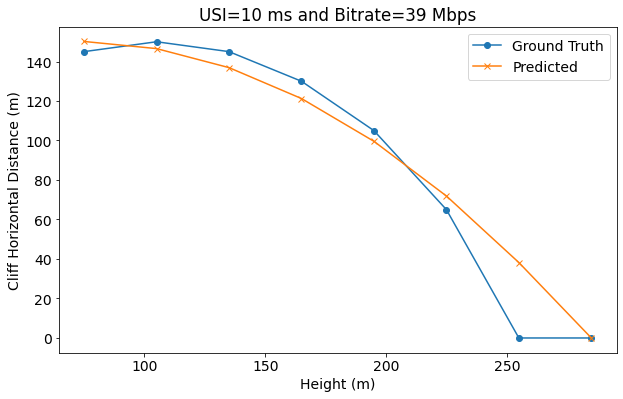

In [14]:
# Plot results
USI = 10
BITRATE = 39
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted')
plt.title(f'USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.legend()

## Support Vector Machine (For Inputs of USI, MCS)

In [ ]:
# Training SVR Model (Height only) - One model per USI and Bitrate combination
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle

link = "Downlink" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]

dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist_height_only/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

for usi in USI:
    for bitrate in BITRATE:
        X_train = []
        y_train = []
        
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            X_train.append([height])
            y_train.append(cliff_hdist)
        
        if len(X_train) == 0:
            print(f"Skipping USI={usi}, Bitrate={bitrate}: No valid cliff distances")
            continue
        
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        param_grid = {
            'C': [10, 100, 1000, 10000, 100000],
            'epsilon': [0.01, 0.001, 0.0001, 0.00001, 0.000001],
            'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1]
        }
        cv = [(slice(None), slice(None))]  # Disable cross-validation
        
        # Use cv=None to disable cross-validation and train/validate on the same data
        svr = SVR(kernel='rbf')
        grid_search = GridSearchCV(svr, param_grid, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=0)
        grid_search.fit(X_train_scaled, y_train)
        
        svr_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        
        # Calculate MAE on training data (same data used for training)
        train_predictions = svr_model.predict(X_train_scaled)
        train_mae = np.mean(np.abs(y_train - train_predictions))
        
        print(f"USI={usi}, Bitrate={bitrate}")
        print(f"  Best parameters: {best_params}")
        print(f"  Training MAE: {train_mae:.4f}")
        print(f"  Training samples: {len(X_train)}\n")
        
        # Save the SVR model and scaler
        model_filename = f"svr_model_usi_{usi}_bitrate_{bitrate}.pkl"
        scaler_filename = f"scaler_usi_{usi}_bitrate_{bitrate}.pkl"
        params_filename = f"best_params_usi_{usi}_bitrate_{bitrate}.txt"
        
        pickle.dump(svr_model, open(os.path.join(save_path, model_filename), 'wb'))
        pickle.dump(scaler, open(os.path.join(save_path, scaler_filename), 'wb'))
        
        with open(os.path.join(save_path, params_filename), 'w') as f:
            f.write(f"Best Parameters for USI={usi}, Bitrate={bitrate}:\n")
            for param, value in best_params.items():
                f.write(f"{param}: {value}\n")
            f.write(f"\nTraining MAE: {train_mae:.4f}\n")
            f.write(f"Training samples: {len(X_train)}\n")

print(f"All models saved to {save_path}")

USI=10, Bitrate=6.5
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=13
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=19.5
  Best parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
  Training MAE: 0.0000
  Training samples: 9

USI=10, Bitrate=26
  Best parameters: {'C': 100000, 'epsilon': 0.0001, 'gamma': 'scale'}
  Training MAE: 0.0001
  Training samples: 9

USI=10, Bitrate=39
  Best parameters: {'C': 100000, 'epsilon': 0.0001, 'gamma': 'scale'}
  Training MAE: 0.0002
  Training samples: 9

USI=10, Bitrate=52
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'gamma': 'auto'}
  Training MAE: 0.0004
  Training samples: 9

USI=10, Bitrate=58.5
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'gamma': 'auto'}
  Training MAE: 0.0002
  Training samples: 9

USI=10, Bitrate=65
  Best parameters: {'C': 100000, 'epsilon': 0.001, 'g

In [23]:
# Testing SVR Model (Height only) - Load per-combination models
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)

# SVR Model Path
svr_model_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist_height_only/{link.lower()}/"

# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])

results = []
for usi in USI:
    for bitrate in BITRATE:
        if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
            continue # An exception is required for this case
        
        # Load the SVR model and scaler for this USI/Bitrate combination
        model_filename = f"svr_model_usi_{usi}_bitrate_{bitrate}.pkl"
        scaler_filename = f"scaler_usi_{usi}_bitrate_{bitrate}.pkl"
        
        model_path = os.path.join(svr_model_path, model_filename)
        scaler_path = os.path.join(svr_model_path, scaler_filename)
        
        # Skip if model doesn't exist for this combination
        if not os.path.exists(model_path):
            print(f"Skipping USI={usi}, Bitrate={bitrate}: Model file not found")
            continue
        
        svr_model = pickle.load(open(model_path, 'rb'))
        scaler = pickle.load(open(scaler_path, 'rb'))
        
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the SVR model on the test dataset
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                X_test = np.array([[height]])
                X_test_scaled = scaler.transform(X_test)
                predicted_cliff_hdist = svr_model.predict(X_test_scaled)[0]
                predicted_cliff_hdist = max(predicted_cliff_hdist, 0)
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)

# Evaluate metrics
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
mean_percent_err = np.mean(percent_err, where=np.array(results_df["Ground Truth Cliff Hdist"].tolist()) != 0) # Avoid division by zero
abs_err = np.abs(err)
mae = np.mean(abs_err)
std_abs_err = np.std(abs_err)
mse = np.mean(err**2)
max_ae = np.max(abs_err)
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Standard Deviation of Absolute Error: {std_abs_err}")
print(f"Mean Percentage Error: {mean_percent_err}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Max Absolute Error: {max_ae}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 3.8391631987432553
Standard Deviation of Absolute Error: 4.108897096320015
Mean Percentage Error: 5.400348045048842
Mean Squared Error (MSE): 31.62220941473159
Max Absolute Error: 23.678200421664016

Combination with Max Absolute Error:
USI                          20.0000
Bitrate                      39.0000
Height                      285.0000
Ground Truth Cliff Hdist      0.0000
Predicted Cliff Hdist        23.6782
Name: 71, dtype: float64


/tmp/ipykernel_1488810/65409441.py:66: RuntimeWarning: divide by zero encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100
/tmp/ipykernel_1488810/65409441.py:66: RuntimeWarning: invalid value encountered in divide
  percent_err = np.abs(err) / np.array(results_df["Ground Truth Cliff Hdist"].tolist()) * 100


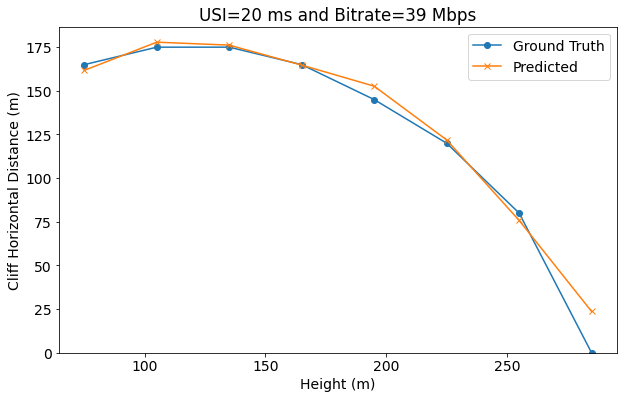

In [24]:
# Plot results
USI = 20
BITRATE = 39
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted')
plt.title(f'USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.ylim(0)
plt.legend()

## Support Vector Regression (For Inputs of Height, USI, MCS)

In [17]:
# Training SVR Model
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pickle

# Training SVR Model
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]

# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

# Calculate reliability
if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

# Collect all training data across USI and Bitrate combinations
X_train = []
y_train = []

for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            cliff_hdist_list.append(cliff_hdist)
            # if cliff_hdist >s 0:  # Only add valid cliff distances
                # X_train.append([height, usi, bitrate])
                # y_train.append(cliff_hdist)
            X_train.append([height, usi, bitrate])
            y_train.append(cliff_hdist)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Standardize features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

""" Fitting with RBF Kernel SVR """
# Define parameter grid for GridSearchCV
param_grid = {
    'C': [10, 100, 1000, 10000, 100000],
    'epsilon': [0.0001, 0.00001, 0.000001, 1e-7, 1e-8, 1e-9],
    'gamma': ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1]
}
# Perform GridSearchCV with 5-fold cross-validation
svr = SVR(kernel='rbf')
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# """ Fitting with poly Kernel SVR """
# # Define parameter grid for GridSearchCV
# param_grid = {
#     'degree': [2, 3],
#     'C': [10, 100, 1000, 10000],
#     'epsilon': [0.1, 0.01, 0.001, 0.0001, 0.00001],
#     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
# }
# # Perform GridSearchCV with 5-fold cross-validation
# svr = SVR(kernel='poly')
# grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)
# grid_search.fit(X_train_scaled, y_train)

# Get best model
svr_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"Best parameters: {best_params}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")
print(f"SVR model trained on {len(X_train)} samples")

# Save the best SVR model and scaler
pickle.dump(svr_model, open(os.path.join(save_path, "svr_model.pkl"), 'wb'))
pickle.dump(scaler, open(os.path.join(save_path, "scaler.pkl"), 'wb'))

# Save best parameters to a file for reference
with open(os.path.join(save_path, "best_params.txt"), 'w') as f:
    f.write(f"Best Parameters:\n")
    for param, value in best_params.items():
        f.write(f"{param}: {value}\n")
    f.write(f"\nBest CV MAE: {-grid_search.best_score_:.4f}\n")

print(f"Model saved to {save_path}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters: {'C': 100, 'epsilon': 1e-06, 'gamma': 'auto'}
Best CV MAE: 73.2156
SVR model trained on 288 samples
Model saved to /media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/video/


In [18]:
# Testing SVR Model
link = "Video" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Testing Dataset Path
test_dataset_file_path = f"/media/research-student/DataDrive/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/{link}_Reliability.csv"
test_data_df = pd.read_csv(test_dataset_file_path)

# SVR Model Path
svr_model_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/svr_cliff_dist/{link.lower()}/"

# Get reliability from the test dataset
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif "Num_Fail_Other" in test_data_df.columns and "Num_Delay_Excd" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"])

# Load the SVR model and scaler
svr_model = pickle.load(open(os.path.join(svr_model_path, "svr_model.pkl"), 'rb'))
scaler = pickle.load(open(os.path.join(svr_model_path, "scaler.pkl"), 'rb'))

results = []
for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            # Get the ground truth cliff horizontal distance from the test dataset
            subset = test_data_df[(test_data_df['UAV_Sending_Interval'] == usi) & (test_data_df['Bitrate'] == bitrate) & (test_data_df['Height'] == height)]
            cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))
        if any(hdist > 0 for hdist in cliff_hdist_list):
            # Evaluate the SVR model on the test dataset
            for height, cliff_hdist in zip(HEIGHT, cliff_hdist_list):
                X_test = np.array([[height, usi, bitrate]])
                X_test_scaled = scaler.transform(X_test)
                predicted_cliff_hdist = svr_model.predict(X_test_scaled)[0]
                results.append({
                    "USI": usi,
                    "Bitrate": bitrate,
                    "Height": height,
                    "Ground Truth Cliff Hdist": cliff_hdist,
                    "Predicted Cliff Hdist": predicted_cliff_hdist
                })

results_df = pd.DataFrame(results)

# Evaluate metrics
err = np.array(results_df["Ground Truth Cliff Hdist"].tolist()) - np.array(results_df["Predicted Cliff Hdist"].tolist())
abs_err = np.abs(err)
mae = np.mean(abs_err)
mse = np.mean(err**2)
rmse = np.sqrt(mse)
max_ae = np.max(abs_err)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Max Absolute Error: {max_ae:.4f}")

# Find where error is the max
max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Mean Absolute Error (MAE): 27.7778
Mean Squared Error (MSE): 3308.1406
Root Mean Squared Error (RMSE): 57.5164
Max Absolute Error: 308.6274

Combination with Max Absolute Error:
USI                          20.000000
Bitrate                      13.000000
Height                      285.000000
Ground Truth Cliff Hdist    420.000000
Predicted Cliff Hdist       111.372578
Name: 47, dtype: float64


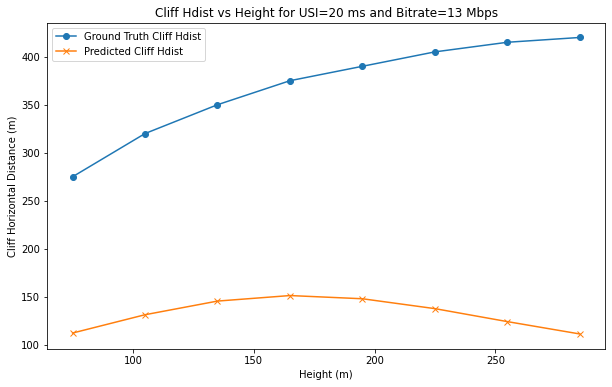

In [19]:
# Plot results
USI = 20
BITRATE = 13
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth Cliff Hdist')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted Cliff Hdist')
plt.title(f'Cliff Hdist vs Height for USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.legend()

## Neural Network Regression (For Inputs of Height, USI, MCS)

In [21]:
# Training Neural Network Model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

class RegressionModel(nn.Module):
	def __init__(self, input_dim: int):
		super(RegressionModel, self).__init__()
		self.model = nn.Sequential(
			nn.Linear(input_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 32),
			nn.ReLU(),
			nn.Linear(32, 16),
			nn.ReLU(),
			nn.Linear(16, 1)
		)
	
	def forward(self, x):
		return self.model(x)
      
# Training Neural Network Model
link = "Downlink" # "Downlink", "Uplink", "Video"
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [60, 90, 120, 150, 180, 210, 240, 270, 300]
EPOCH = 5000

# Training Dataset Path
dataset_file_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/data_processed/{link}_Reliability.csv"
# Save Model Path
save_path = f"/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/nn_cliff_dist/{link.lower()}/"

os.makedirs(save_path, exist_ok=True)
data_df = pd.read_csv(dataset_file_path)

# Calculate reliability
if "Num_Sent" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / data_df["Num_Sent"]
elif "Num_Fail_Other" in data_df.columns and "Num_Delay_Excd" in data_df.columns and "Num_Reliable" in data_df.columns:
    data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])

# Collect all training data across USI and Bitrate combinations
X_train = []
y_train = []

for usi in USI:
    for bitrate in BITRATE:
        cliff_hdist_list = []
        for height in HEIGHT:
            subset = data_df[(data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate) & (data_df['Height'] == height)]
            cliff_hdist = find_cliff_hdist(subset, threshold=0.99)
            cliff_hdist_list.append(cliff_hdist)
            X_train.append([height, usi, bitrate])
            y_train.append(cliff_hdist)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Standardize features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
input_dim = X_train.shape[1]
model = RegressionModel(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop with early stopping
best_val_loss = float('inf')
patience_counter = 0
patience = 5000
best_model_state = None

for epoch in range(EPOCH):

    # Training phase
    model.train()
    train_loss = 0.0
    train_mae = 0.0
    num_batches = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_mae += torch.mean(torch.abs(y_pred - y)).item()
        num_batches += 1

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    num_val_batches = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_pred = model(x)
        loss = criterion(y_pred, y)
        val_loss += loss.item()
        val_mae += torch.mean(torch.abs(y_pred - y)).item()
        num_val_batches += 1

    train_loss /= num_batches
    train_mae /= num_batches
    val_loss /= num_val_batches
    val_mae /= num_val_batches

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCH}], Loss: {train_loss}, MAE: {train_mae}, Val Loss: {val_loss}, Val MAE: {val_mae}")

    # Early stopping and model checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_mae = val_mae
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        # Save best model
        torch.save(best_model_state, os.path.join(save_path, "best_model.h5"))
    # UNCOMMENT BELOW TO ENABLE EARLY STOPPING
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model and save final version
if best_model_state is not None:
    model.load_state_dict(best_model_state)
torch.save(model.state_dict(), os.path.join(save_path, "final_model.h5"))

# Save the scaler for later use
pickle.dump(scaler, open(os.path.join(save_path, "scaler.pkl"), 'wb'))

# Print best validation performance
print(f"Best Validation Loss: {best_val_loss:.4f}, Best Validation MAE: {best_val_mae:.4f}")

Using device: cuda
Epoch [1/5000], Loss: 43944.942708333336, MAE: 152.14477962917752, Val Loss: 43929.64800347222, Val MAE: 152.096310933431
Epoch [50/5000], Loss: 7531.806423611111, MAE: 60.01923370361328, Val Loss: 7424.428548177083, Val MAE: 59.05092536078559
Epoch [100/5000], Loss: 3566.2009548611113, MAE: 38.8126335144043, Val Loss: 3486.8160536024307, Val MAE: 36.90005429585775
Epoch [150/5000], Loss: 2178.543975830078, MAE: 28.410768296983505, Val Loss: 2124.6783040364585, Val MAE: 27.76513926188151
Epoch [200/5000], Loss: 1565.804463704427, MAE: 21.748101658291286, Val Loss: 1518.8576524522568, Val MAE: 21.267791112263996
Epoch [250/5000], Loss: 1149.853244357639, MAE: 18.87630950080024, Val Loss: 1092.801233927409, Val MAE: 18.249629762437607
Epoch [300/5000], Loss: 620.6959737141927, MAE: 15.593218061659071, Val Loss: 630.4653811984592, Val MAE: 16.402800665961372
Epoch [350/5000], Loss: 349.35297139485675, MAE: 12.859879069858128, Val Loss: 347.86155192057294, Val MAE: 12.94

In [26]:
# NN Testing Cell (for model trained above)
import os
import pickle
import numpy as np
import pandas as pd
import torch

link = "Downlink"  # must match the trained model folder
USI = [10, 20, 66.7, 100]
BITRATE = [6.5, 13, 19.5, 26, 39, 52, 58.5, 65]
HEIGHT = [75, 105, 135, 165, 195, 225, 255, 285]

# Paths
test_dataset_file_path = (
    f"/media/research-student/DataDrive/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/"
    f"data_processed_complete/{link}_Reliability.csv"
)
model_dir = (
    f"/media/research-student/KingstonSSD/FANET_Dataset/"
    f"Dataset_NP100000_DJISpark/nn_cliff_dist/{link.lower()}/"
)

model_path = os.path.join(model_dir, "final_model.h5")
scaler_path = os.path.join(model_dir, "scaler.pkl")

# Load test data
test_data_df = pd.read_csv(test_dataset_file_path)

# Reliability calculation
if "Num_Sent" in test_data_df.columns and "Num_Reliable" in test_data_df.columns:
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / test_data_df["Num_Sent"]
elif all(c in test_data_df.columns for c in ["Num_Fail_Other", "Num_Delay_Excd", "Num_Reliable"]):
    test_data_df["Reliability"] = test_data_df["Num_Reliable"] / (
        test_data_df["Num_Reliable"] + test_data_df["Num_Delay_Excd"] + test_data_df["Num_Fail_Other"]
    )
else:
    raise ValueError("Required columns for Reliability were not found.")

# Load scaler + model
scaler = pickle.load(open(scaler_path, "rb"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RegressionModel(input_dim=3).to(device)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

# Inference
results = []
with torch.no_grad():
    for usi in USI:
        for bitrate in BITRATE:
            if link == "Uplink" and usi == 66.7 and bitrate == 6.5:
                # This case has essentially no valid cliff dist, but our training data is a little inconsistent (just at one data point)
                continue
            if link == "Downlink" and usi == 66.7 and bitrate == 6.5:
                continue
            if link == "Uplink" and usi == 10 and bitrate == 26:
                continue

            cliff_hdist_list = []
            for height in HEIGHT:
                subset = test_data_df[
                    (test_data_df["UAV_Sending_Interval"] == usi)
                    & (test_data_df["Bitrate"] == bitrate)
                    & (test_data_df["Height"] == height)
                ]
                cliff_hdist_list.append(find_cliff_hdist(subset, threshold=0.99))

            if any(h > 0 for h in cliff_hdist_list):
                for height, gt in zip(HEIGHT, cliff_hdist_list):
                    x = np.array([[height, usi, bitrate]], dtype=np.float32)
                    x_scaled = scaler.transform(x)
                    x_tensor = torch.tensor(x_scaled, dtype=torch.float32, device=device)
                    pred = model(x_tensor).item()
                    pred = max(pred, 0.0)  # optional clamp
                    results.append({
                        "USI": usi,
                        "Bitrate": bitrate,
                        "Height": height,
                        "Ground Truth Cliff Hdist": float(gt),
                        "Predicted Cliff Hdist": float(pred),
                    })

results_df = pd.DataFrame(results)

# Metrics
err = np.array(results_df["Ground Truth Cliff Hdist"]) - np.array(results_df["Predicted Cliff Hdist"])
abs_err = np.abs(err)
mae = np.mean(abs_err)
mse = np.mean(err**2)
rmse = np.sqrt(mse)
max_ae = np.max(abs_err)

with np.errstate(divide="ignore", invalid="ignore"):
    percent_err = np.where(results_df["Ground Truth Cliff Hdist"].to_numpy() != 0,
                           abs_err / results_df["Ground Truth Cliff Hdist"].to_numpy() * 100,
                           np.nan)
mean_percent_err = np.nanmean(percent_err)
max_percent_err = np.nanmax(percent_err)
# Percentage of errors below 10
percent_abs_err_below_10 = len(abs_err[abs_err < 10]) / len(abs_err) * 100
percent_perc_err_below_10 = len(percent_err[percent_err < 10]) / len(percent_err) * 100

print(f"Samples evaluated: {len(results_df)}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Percentage Error: {mean_percent_err:.4f}")
print(f"Max Absolute Error: {max_ae:.4f}")
print(f"Max Percentage Error: {max_percent_err:.4f}")
print(f"Percentage of samples with Absolute Error < 10: {percent_abs_err_below_10:.2f}%")
print(f"Percentage of samples with Percentage Error < 10: {percent_perc_err_below_10:.2f}%")

max_err_index = np.argmax(abs_err)
print("\nCombination with Max Absolute Error:")
print(results_df.iloc[max_err_index])

Samples evaluated: 224
Mean Absolute Error (MAE): 3.3225
Mean Squared Error (MSE): 30.2204
Root Mean Squared Error (RMSE): 5.4973
Mean Percentage Error: 6.6837
Max Absolute Error: 26.6325
Max Percentage Error: 532.6504
Percentage of samples with Absolute Error < 10: 93.30%
Percentage of samples with Percentage Error < 10: 69.64%

Combination with Max Absolute Error:
USI                          20.000000
Bitrate                      52.000000
Height                      165.000000
Ground Truth Cliff Hdist      5.000000
Predicted Cliff Hdist        31.632521
Name: 83, dtype: float64


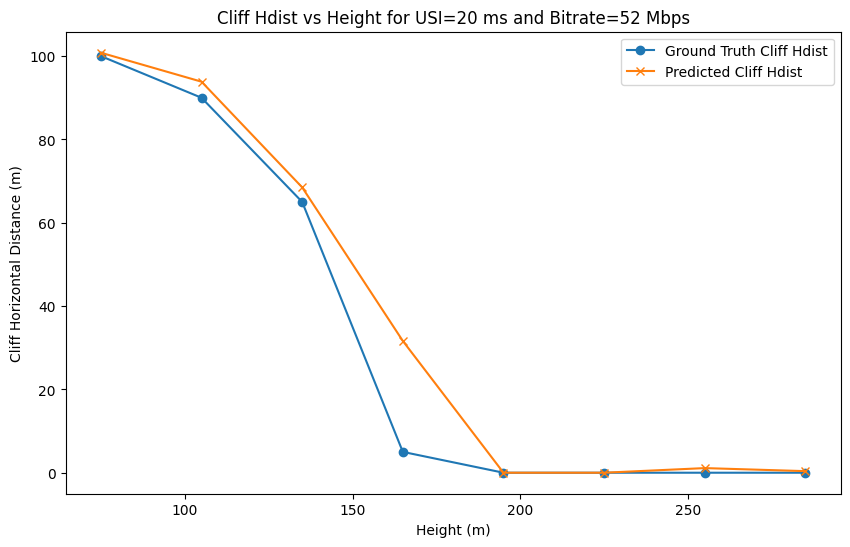

In [27]:
# Plot results
USI = 20
BITRATE = 52
subset_results = results_df[(results_df['USI'] == USI) & (results_df['Bitrate'] == BITRATE)]
plt.figure(figsize=(10, 6))
plt.plot(subset_results['Height'], subset_results['Ground Truth Cliff Hdist'], marker='o', label='Ground Truth Cliff Hdist')
plt.plot(subset_results['Height'], subset_results['Predicted Cliff Hdist'], marker='x', label='Predicted Cliff Hdist')
plt.title(f'Cliff Hdist vs Height for USI={USI} ms and Bitrate={BITRATE} Mbps')
plt.xlabel('Height (m)')
plt.ylabel('Cliff Horizontal Distance (m)')
plt.legend()